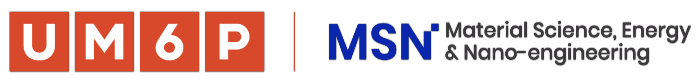

##***Machine Learning for Materials Science***
##***Dr. Ahmed Dimokrati***
###University Mohammed 6 Polytechnic (UM6P),
###College of Chemistry Science and Engineering (CCSE),
###Materials Science, Energy, and Nanoengineering department (MSN).
###2025-2026

* The following code cell sets up the environment by installing some necessary packages and mounting google drive for storage.

In [ ]:
# ===== Colab bootstrap: install packages & mount Drive =====
import sys
# Install packages (modify list as needed)
!pip install --quiet matminer pymatgen scikit-learn pandas numpy matplotlib seaborn shap
# Optional: upgrade pip / other packages
#!pip install --upgrade --quiet pip
# Mount Google Drive for persistent storage
from google.colab import drive
drive.mount('/content/drive')
print("Bootstrap complete. Adjust package list if necessary.")

Now let's perform a first machine learning computation: "Linear regression"
  * Low-level implementation, using numpy, of a direct resolution for a linear regression
  * We have the following equation: $Y=XΘ + N$
  * $N$ is a noise vector
  * $Θ$ is data-vector with two components $(a,b)$ such that: $y=ax+b$

* This code creates a synthetic dataset for a simple linear relationship:

* $y=a⋅x+b+N$

👉 You are simulating an experiment where a property depends linearly on another, but with measurement noise.

For example these data can represent:

* x: composition, temperature, pressure…
* y: property (band gap, strength, conductivity…)

In [132]:
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
import sys
from IPython.display import Markdown


nb    = 1000     # number of data points (like number of experiments)
xmin  = 0       # min value of input variable x
xmax  = 10      # max value of input variable x
a     = 4       # slope
b     = 2       # intercept
noise = 4       # noise magnitude


* At this level we defined the set of parameters that will be used to generate our noisy data with the true line given by:

 $$ y = 4x+2 $$

* Next we define the vector $\Theta$ such that:

$$ \Theta = (a,b) = (4,2) $$

* θ = parameters the model tries to learn

In [90]:
theta = np.array([[a],[b]])

In [91]:
Xc1 = np.ones((nb,1))                        # define the first column of X as 100 elements with one values
Xc2 = np.random.uniform(xmin,xmax,(nb,1))    # define the second column of X as 100 random values between xmin and xmax (random sampling)
#Xc2 = np.linspace(xmin, xmax, 100)            # Linear sampling
X = np.c_[ Xc1, Xc2 ]                        # Gather both columns Xc1 and Xc2 in a matrix form

* Here we have defined the matrix X such that:
  $$ X = \begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
1 & x_3 \\
.. & .. \\
1 & x_{100}
\end{bmatrix}$$


In [92]:
# ---- Noise
N = noise * np.random.normal(0,1,(nb,1))

# ---- Vecteur Y
Y = (X @ theta) + N

# print("X:\n",X,"\nY:\n ",Y)

* Here we have initialized the noise as gaussian distribution between 0 and 1
* Then the $Y$ vector is define as the product of the $X$ vector with $\theta$ + the noise
* At this level we have generated a set of 100 data points $Y$ with fluctuating values arround the line given by the slope $a=4$ and the intercept $b=2$.
* Let's see what this looks like !!

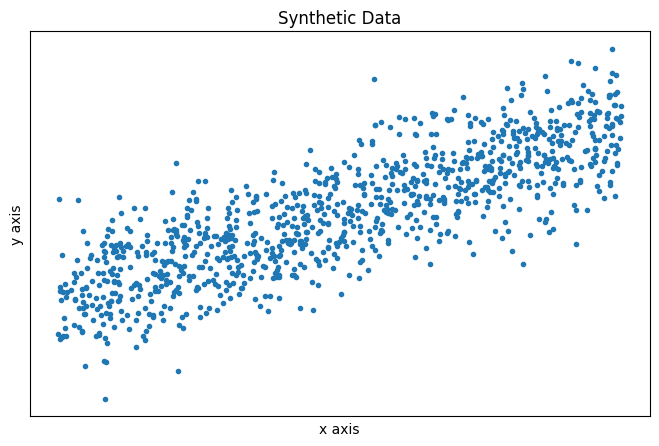

In [93]:
width = 8
height = 5

fig, ax = plt.subplots()
fig.set_size_inches(width,height)
ax.plot(X[:,1], Y, ".")
ax.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
ax.set_xlabel('x axis')
ax.set_ylabel('y axis')
plt.title("Synthetic Data")
plt.show()

* Now we get to the main point. Having this noisy data how can I retrieve the parameteres $\hat{\Theta}(a,b)$ that approaches the true measurments ??
* We will try to minimize what we call a loss function (cost function):
* The cost function, classically used in the case of linear regressions, is the root mean square error:

* $$ RMSE = \sqrt{\frac{1}{n} ∑_{i=1}^{n} (y_i - \hat{y_i})^2}$$
* It can be shown that the optimal solution $\hat\Theta$ that minimizes the loss function above can be given by the "normal equation":
* $$ \hat\Theta = (X^T.X)^{-1}.X^{T}.Y $$

In [94]:
theta_hat_1 = np.linalg.inv(X.T @ X) @ X.T @ Y

print("Theta :\n",theta,"\n\ntheta hat :\n",theta_hat_1)

Theta :
 [[4]
 [2]] 

theta hat :
 [[3.76305195]
 [2.04809207]]


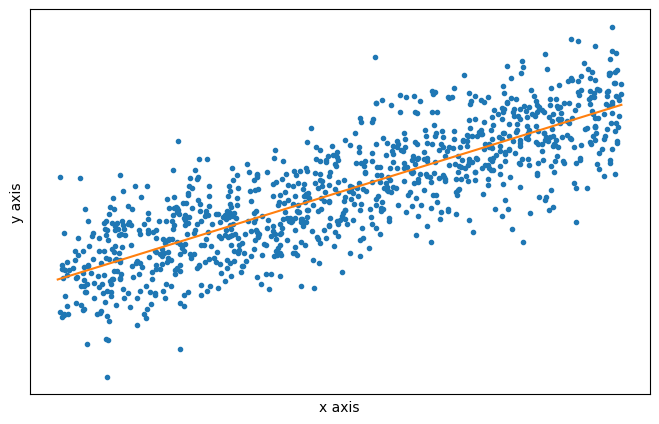

In [95]:
Xd = np.array([[1,xmin], [1,xmax]])
Yd = Xd @ theta_hat_1

fig, ax = plt.subplots()
fig.set_size_inches(width,height)
ax.plot(X[:,1], Y, ".")
ax.plot(Xd[:,1], Yd, "-")
ax.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
ax.set_xlabel('x axis')
ax.set_ylabel('y axis')
plt.show()

* Now let's try a different approach. Instead of using an analytical formula, let's do it iteratively !!
* This will be acieaved using a key concept in machine learning known as the gradient descent.

In [119]:
# Initialize theta randomly
theta_gd = np.random.randn(2,1)



# Learning rate (step size)
alpha = 0.01

# Number of iterations
n_iter = 5000

# Number of samples
m = len(Y)

print("Initial theta:\n", theta_gd)

Initial theta:
 [[-0.15017727]
 [-1.55505801]]


In [120]:
loss_history = []

for i in range(n_iter):

    # Predictions
    Y_pred = X @ theta_gd

    # Error
    error = Y_pred - Y

    # Compute gradient
    gradient = (2/m) * X.T @ error

    # Update parameters
    theta_gd = theta_gd - alpha * gradient

    # Compute loss
    loss = (1/m) * np.sum(error**2)
    loss_history.append(loss)

print("Theta learned with Gradient Descent:\n", theta_gd)

Theta learned with Gradient Descent:
 [[3.76305195]
 [2.04809207]]


In [121]:
theta_closed = np.linalg.lstsq(X, Y, rcond=None)[0]

print("True theta:\n", theta)
print("\nThe normal equation solution:\n", theta_hat_1)
print("\nClosed-form solution:\n", theta_closed)
print("\nGradient Descent solution:\n", theta_gd)

True theta:
 [[4]
 [2]]

The normal equation solution:
 [[3.76305195]
 [2.04809207]]

Closed-form solution:
 [[3.76305195]
 [2.04809207]]

Gradient Descent solution:
 [[3.76305195]
 [2.04809207]]


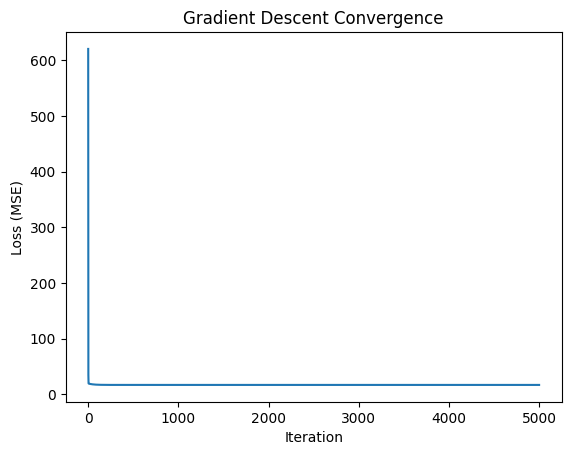

In [122]:
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss (MSE)")
plt.title("Gradient Descent Convergence")
plt.show()

### Why use iterative approachs such as gradient descent ??
* The normal equation requires that $(X^T.X)$ is invertible (not always garanteed)
* If the matrix is invertible, the computational cost is very high for matrix inversion ($O(n^3)$)!


* We can also use modern ML librairies that makes the gradient descent computation more compact such as Pytorch and Keras
* In the following is an example using Pytorch:

In [123]:
import torch

# Convert data to torch tensors
X_t = torch.tensor(X, dtype=torch.float32)
Y_t = torch.tensor(Y, dtype=torch.float32)

# Define linear model (2 inputs → 1 output)
model = torch.nn.Linear(2, 1, bias=False)

# Loss function
loss_fn = torch.nn.MSELoss()

# Optimizer (gradient descent)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Training loop
for i in range(1000):
    # Forward pass
    Y_pred = model(X_t)

    # Compute loss
    loss = loss_fn(Y_pred, Y_t)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()

    # Update parameters
    optimizer.step()

# Extract learned parameters
theta_torch = model.weight.detach().numpy().T

print("Theta (PyTorch):\n", theta_torch)

Theta (PyTorch):
 [[3.7372015]
 [2.0519657]]


In the following is another example using Keras:

In [124]:
import tensorflow as tf
from tensorflow import keras

# Define model
model = keras.Sequential([
    keras.layers.Dense(1, use_bias=False, input_shape=(2,))
])

# Compile model
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01),
              loss='mse')

# Train model
model.fit(X, Y, epochs=1000, verbose=0)

# Get weights
theta_keras = model.get_weights()[0]

print("Theta (Keras):\n", theta_keras)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Theta (Keras):
 [[3.7953548]
 [2.1531014]]


### Notice some slight diferences in the results using diffrent implementations, altough we used the same parameters!! What could be the reason ??